In [1]:
import os
import pandas as pd
import cv2
import torch
import torch.nn.utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
import json
print("All modules imported")

All modules imported


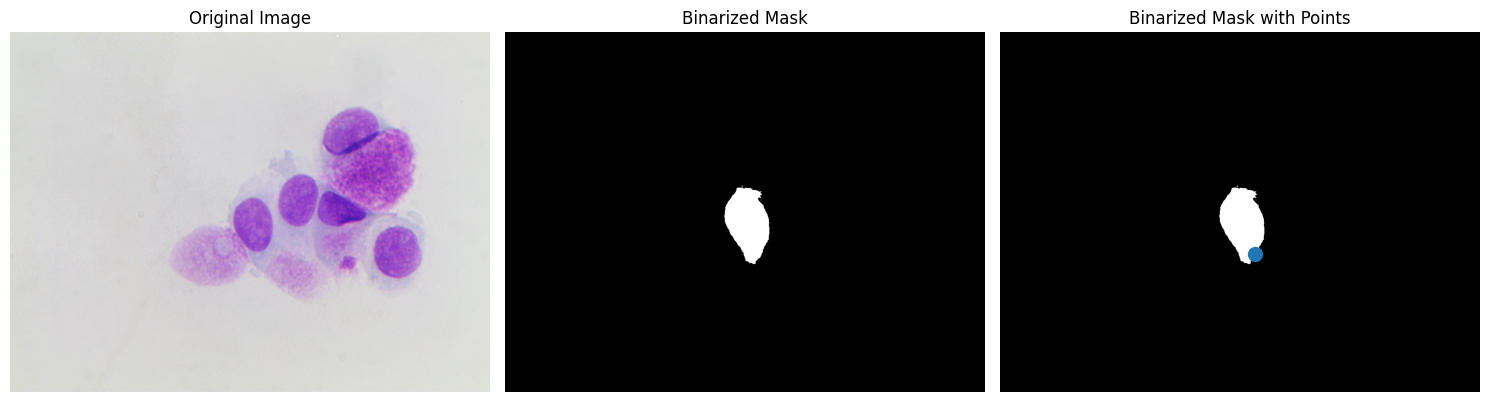

In [2]:
data_dir = r"C:\Users\Admin\Desktop\New_Dataset"
images_dir = os.path.join(data_dir, "images")
masks_dir = os.path.join(data_dir, "masks")

with open(r"C:\Users\Admin\Desktop\New_Dataset\labels.json") as f:
    data=json.load(f)

all_data = []
all_images=[]
for entry in data['images']:
    image_name = entry['image_name']
    masks = [label['mask_file'] for label in entry['labels']]
    
    all_images.append({
        "image": os.path.join(images_dir, image_name),
        "masks": [os.path.join(masks_dir, mask) for mask in masks],
        "labels": [label['label'] for label in entry['labels']]
    })

train_images, test_images = train_test_split(all_images, test_size=0.2, random_state=42)

train_data = []
for entry in train_images:
    for mask in entry['masks']:
        train_data.append({
            "image": entry["image"],
            "annotation": mask
        })

test_data = []
for entry in test_images:
    for mask in entry['masks']:
        test_data.append({
            "image": entry["image"],
            "annotation": mask
        })
        
def read_batch(data, visualize_data=False):
    # Select a random entry
    ent = data[np.random.randint(len(data))]

    # Get full paths
    Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
    ann_map = cv2.imread(ent["annotation"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale

    if Img is None or ann_map is None:
        print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotation']}")
        return None, None, None, 0

    # Resize image and mask
    r = np.min([1024 / Img.shape[1], 1024 / Img.shape[0]])  # Scaling factor
    Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
    ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
    points=[]
    inds = np.unique(ann_map)[1:]
    for ind in inds:
        mask = (ann_map == ind).astype(np.uint8)
        binary_mask = np.maximum(binary_mask, mask)
    coords = np.argwhere(binary_mask > 0)
    if len(coords) > 0:
        for _ in inds:
            yx = np.array(coords[np.random.randint(len(coords))])
            points.append([yx[1], yx[0]])
    points = np.array(points)

    if visualize_data:
        # Plotting the images and points
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(Img)
        plt.axis('off')
        # Segmentation Mask (binary_mask)
        plt.subplot(1, 3, 2)
        plt.title('Binarized Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        # Mask with Points in Different Colors
        plt.subplot(1, 3, 3)
        plt.title('Binarized Mask with Points')
        plt.imshow(binary_mask, cmap='gray')
        colors = list(mcolors.TABLEAU_COLORS.values())
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=colors[i % len(colors)], s=100, label=f'Point {i+1}')  # Corrected to plot y, x order

        # plt.legend()
        plt.axis('off')

        plt.tight_layout()
        plt.show()
        
    binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
    binary_mask = binary_mask.transpose((2, 0, 1))
    points = np.expand_dims(points, axis=1)

    # Return the image, binarized mask, points, and number of masks
    return Img, binary_mask, points, len(inds)

Img1, masks1, points1, num_masks = read_batch(train_data, visualize_data=True)


In [3]:
def read_image(image_path, mask_path):  # read and resize image and mask
    img = cv2.imread(image_path)[..., ::-1]  # Convert BGR to RGB
    mask = cv2.imread(mask_path, 0)
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])
    img = cv2.resize(img, (int(img.shape[1] * r), int(img.shape[0] * r)))
    mask = cv2.resize(mask, (int(mask.shape[1] * r), int(mask.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    return img, mask

def get_points(mask, num_points):  # Sample points inside the input mask
    points = []
    coords = np.argwhere(mask > 0)
    for i in range(num_points):
        yx = np.array(coords[np.random.randint(len(coords))])
        points.append([[yx[1], yx[0]]])
    return np.array(points)

In [4]:
all_data = []

import albumentations as A
from albumentations.pytorch import ToTensorV2
import random
from PIL import Image
from torchvision import transforms


for entry in data['images']:
    image_name = entry['image_name']
    image_path = os.path.join(images_dir, image_name)

    image = Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path = os.path.join(masks_dir, label_info['mask_file'])
        label = label_info['label']

        mask = Image.open(mask_path).convert("L")

        masked_image = Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image = np.array(masked_image)

        all_data.append({"masked_image": masked_image, "label": label})

random.shuffle(all_data)
train_data, test_data = train_test_split(all_data, test_size=0.2, random_state=42)

class MaskedImageDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None, augmentations=None, num_copies=1):
        self.data = data
        self.transform = transform
        self.augmentations = augmentations
        self.num_copies = num_copies
        self.expanded_data = self._expand_data()

    def _expand_data(self):
        expanded_data = []
        for item in self.data:
            expanded_data.append(item)
            for _ in range(self.num_copies - 1):
                augmented_item = item.copy()
                image = item["masked_image"]
                
                if not isinstance(image, np.ndarray):
                    image = np.array(image)

                augmented_data = self.augmentations(image=image)
                augmented_item["masked_image"] = augmented_data["image"]
                expanded_data.append(augmented_item)
                
        return expanded_data

    def __getitem__(self, idx):
        item = self.expanded_data[idx]
        masked_image = item["masked_image"]
        label = item["label"]


        if self.augmentations and isinstance(masked_image, np.ndarray):
            masked_image = np.array(masked_image)

        if self.augmentations:
            augmented = self.augmentations(image=masked_image)
            masked_image = augmented["image"]
            
        masked_image=torch.tensor(masked_image, dtype=torch.float32)

        if self.transform and not isinstance(masked_image, torch.Tensor):
            masked_image = self.transform(masked_image)
        
        return masked_image, label

    def __len__(self):
        return len(self.expanded_data)
        
albumentations_augmentations = A.Compose([
    A.RandomBrightnessContrast(p=1.0),
    A.VerticalFlip(p=1.0),
    A.Rotate(p=1.0)
])

torchvision_transform = transforms.Compose([
    transforms.ToTensor(),
    ToTensorV2()
])


train_dataset = MaskedImageDataset(
    train_data, 
    transform=torchvision_transform, 
    augmentations=albumentations_augmentations, 
    num_copies=3
)

test_dataset = MaskedImageDataset(
    test_data, 
    transform=torchvision_transform 
)


train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)

In [5]:
len(train_loader)

650

torch.Size([768, 1024, 3])


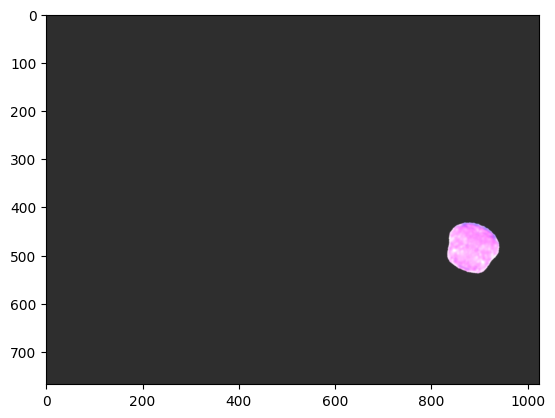

In [6]:
import cv2
data_iter = iter(train_loader)
images, labels = next(data_iter)

image = images[2]
label = labels[2]
print(image.shape) 

image=image.numpy()

image_np = (image * 1).astype(np.uint8)

plt.imshow(image_np)
plt.show()

Using cache found in C:\Users\Admin/.cache\torch\hub\pytorch_vision_v0.10.0
Using cache found in C:\Users\Admin/.cache\torch\hub\pytorch_vision_v0.10.0



=== Fold 1/4 ===


Fold 1 Epoch [1/30] - Loss: 0.5795, Training Accuracy: 42.86%
Epoch validation accuracy: 60.308


Fold 1 Epoch [2/30] - Loss: 0.3391, Training Accuracy: 55.08%
Epoch validation accuracy: 62.462


Fold 1 Epoch [3/30] - Loss: 0.3143, Training Accuracy: 59.29%
Epoch validation accuracy: 68.462


...

Fold 4 Epoch [26/30] - Loss: 0.1652, Training Accuracy: 77.83%
Epoch validation accuracy: 79.045


Fold 4 Epoch [27/30] - Loss: 0.1692, Training Accuracy: 77.22%
Epoch validation accuracy: 76.425


Fold 4 Epoch [28/30] - Loss: 0.1651, Training Accuracy: 76.45%
Epoch validation accuracy: 76.888


Fold 4 Epoch [29/30] - Loss: 0.1613, Training Accuracy: 77.68%
Epoch validation accuracy: 76.425


Fold 4 Epoch [30/30] - Loss: 0.1615, Training Accuracy: 77.48%
Epoch 00030: reducing learning rate of group 0 to 5.0000e-07.
Epoch validation accuracy: 77.966
Fold 4 Validation Accuracy: 77.97%, Test Accuracy: 81.11%

=== Cross-Validation Results ===
Average Validation Accuracy: 76.68%
Average Test Accuracy: 80.07%


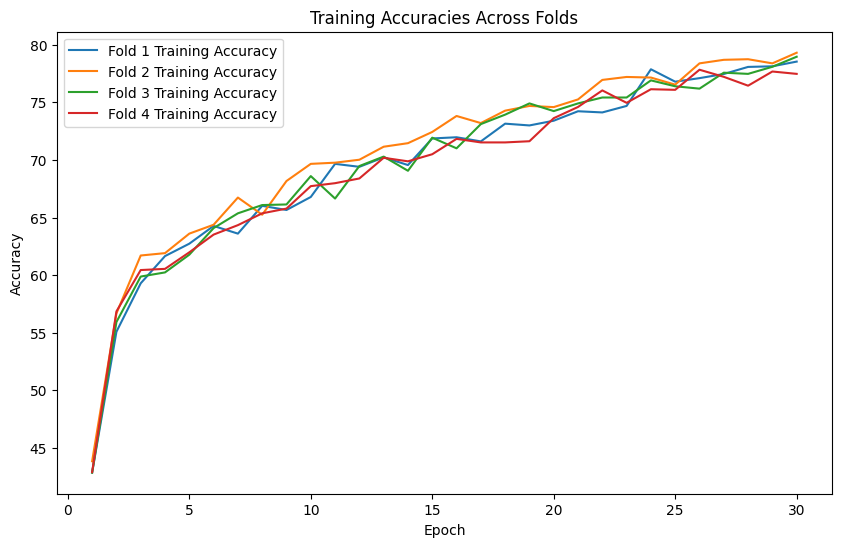

In [8]:
from torch.optim import SGD, Adam
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

k=4
batch_size=4
fold_train_accuracies = []
fold_val_accuracies = []
fold_test_accuracies = []

dataset = train_dataset

kf = KFold(n_splits=k, shuffle=True, random_state=42)

num_classes = len(set(label for entry in train_images for label in entry["labels"]))
classifier = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(classifier.parameters(), lr=0.00005)
num_epochs = 30

label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}

train_accuracies, test_accuracies, train_losses = [], [], []
checkpoint_dir = r"C:\Users\Admin\Documents\mnet_checks"

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    best_fva=0
    print(f"\n=== Fold {fold+1}/{k} ===")

    train_subset = torch.utils.data.Subset(dataset, train_idx)
    val_subset = torch.utils.data.Subset(dataset, val_idx)
    train_loader_kfold = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader_kfold = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Reinitializing model, optimizer, scheduler and criterion for each fold
    classifier = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
    classifier.fc = nn.Sequential(
        nn.Linear(classifier.last_channel, 512),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(512, num_classes)
    )
    classifier.to(device)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(classifier.parameters(), lr=0.00005)

    # Training Loop
    fold_train_accuracy = []
    fold_val_accuracy = []

    for epoch in range(num_epochs):
        classifier.train()
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0
        total_val_loss=0.0

        progress_bar = tqdm(train_loader_kfold, desc=f"Fold {fold+1} Epoch {epoch+1}/{num_epochs}", leave=False)
        
        # Processing one epoch within each fold
        for masked_images, labels in progress_bar:
            masked_images = masked_images.permute(0, 3, 1, 2)
            masked_images = masked_images.to(device)
            optimizer.zero_grad()

            outputs = classifier(masked_images)
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            loss = criterion(outputs, numeric_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == numeric_labels).sum().item()
            total_predictions += len(numeric_labels)

            avg_loss = running_loss / total_predictions
            accuracy = correct_predictions / total_predictions * 100
            progress_bar.set_postfix(loss=avg_loss, accuracy=f"{accuracy:.2f}%")
            
        # Printing epoch metrics
        print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Training Accuracy: {accuracy:.2f}%")
        fold_train_accuracy.append(accuracy)  # Appending accuracy of each epoch to one list
        
        # Getting validation results for the epoch
        classifier.eval()
        correct_val_predictions, total_val_predictions = 0, 0
        with torch.no_grad():
            for masked_images, labels in val_loader_kfold:
                masked_images = masked_images.permute(0, 3, 1, 2)
                masked_images = masked_images.to(device)
                outputs = classifier(masked_images)
                numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
                _, predicted = torch.max(outputs, 1)
                correct_val_predictions += (predicted == numeric_labels).sum().item()
                total_val_predictions += len(numeric_labels)
                loss = criterion(outputs, numeric_labels)
                total_val_loss += loss.item()

        average_val_loss = total_val_loss / len(val_loader_kfold)
        scheduler.step(average_val_loss) # Implementing Reduce LR On Plateau here
        val_accuracy = correct_val_predictions / total_val_predictions * 100
        print(f"Epoch validation accuracy: {val_accuracy:.3f}")
        fold_val_accuracy.append(val_accuracy) # Appending epoch validation accuracy to one list
        if val_accuracy>best_fva:
            best_fva=val_accuracy
            checkpoint_path = os.path.join(checkpoint_dir, f"classifier_epoch_{epoch+1}_fold{fold+1}_{val_accuracy:.3f}.pth") # Saving
            torch.save(classifier.state_dict(), checkpoint_path)
            
    # Appending the list of all epoch accuracies in a fold to another list of fold accuracies
    fold_train_accuracies.append(fold_train_accuracy)
    fold_val_accuracies.append(fold_val_accuracy)

    # Evaluation on test_loader, once per each fold
    correct_test_predictions, total_test_predictions = 0, 0
    classifier.eval()
    with torch.no_grad():
        for masked_images, labels in test_loader:
            masked_images=masked_images.permute(0,3,1,2)
            masked_images = masked_images.to(device)
            outputs = classifier(masked_images)
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            _, predicted = torch.max(outputs, 1)
            correct_test_predictions += (predicted == numeric_labels).sum().item()
            total_test_predictions += len(numeric_labels)

    test_accuracy = correct_test_predictions / total_test_predictions * 100
    fold_test_accuracies.append(test_accuracy)
    # checkpoint_path = os.path.join(checkpoint_dir, f"classifier_epoch_{epoch+1}_TA_{test_accuracy}_FVA_{fold_val_accuracy[-1]}.pth")
    # Printing the fold's best validation and test accuracy
    print(f"Fold {fold+1} Validation Accuracy: {fold_val_accuracy[-1]:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

# Cross-Validation Summary
print("\n=== Cross-Validation Results ===")
avg_val_accuracy = sum([acc[-1] for acc in fold_val_accuracies]) / k
avg_test_accuracy = sum(fold_test_accuracies) / k
print(f"Average Validation Accuracy: {avg_val_accuracy:.2f}%")
print(f"Average Test Accuracy: {avg_test_accuracy:.2f}%")

plt.figure(figsize=(10, 6))
for fold_idx, train_acc in enumerate(fold_train_accuracies):
    plt.plot(range(1, num_epochs + 1), train_acc, label=f"Fold {fold_idx + 1} Training Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracies Across Folds')
plt.show()